# Hotel Booking Cancellation Analysis

## Introduction

This notebook focuses on one core business problem: booking cancellations. The goal is to measure how serious the cancellation problem is, estimate its revenue impact, and identify which factors are most strongly associated with higher cancellation rates.


## Goal and North Star Question

**Goal**: Understand booking cancellation patterns and identify the drivers most associated with higher cancellation rates.

**North Star Question**: What drives cancellation and how can hotels improve it?


## Key Metrics
To ensure that the analysis remains aligned with business objectives(stakeholder = Revenue Dept.), key metrics were defined upfront, including cancellation rate, booking volume, and ADR.

While cancellation rate captures behavioral risk, it alone is insufficient to assess business impact. By incorporating booking volume and ADR, the analysis is able to evaluate cancellations from both scale and value perspectives, providing a more comprehensive view of revenue impact and enabling more precise prioritization of optimization strategies.

1. **ADR**: average room price per booking.
2. **Cancellation Rate**: `mean(is_canceled)`.
3. **Revenue Loss Proxy**: `adr * is_canceled`.


In [11]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["legend.title_fontsize"] = 9

CITY_COLOR = "#4C78A8"
RESORT_COLOR = "#F58518"
OVERALL_COLOR = "#54A24B"
NEUTRAL_COLOR = "#B3B3B3"
CITY_LIGHT = "#A0CBE8"
RESORT_LIGHT = "#FFBE7D"

HOTEL_ORDER = ["City Hotel", "Resort Hotel"]
HOTEL_PALETTE = {"City Hotel": CITY_COLOR, "Resort Hotel": RESORT_COLOR}
HOTEL_LIGHT_PALETTE = {"City Hotel": CITY_LIGHT, "Resort Hotel": RESORT_LIGHT}
HOTEL_HEATMAPS = {"City Hotel": "Blues", "Resort Hotel": "Oranges"}

LEAD_TIME_BINS = [-1, 7, 30, 90, 180, np.inf]
LEAD_TIME_LABELS = ["0-7", "8-30", "31-90", "91-180", "181+"]

DEPOSIT_HEATMAP_ORDER = ["No Deposit", "Non Refund", "Refundable"]
DEPOSIT_STACK_ORDER = ["Refundable", "Non Refund", "No Deposit"]
CITY_DEPOSIT_COLORS = {"Refundable": CITY_LIGHT, "Non Refund": CITY_COLOR, "No Deposit": "#1F4E79"}
RESORT_DEPOSIT_COLORS = {"Refundable": RESORT_LIGHT, "Non Refund": RESORT_COLOR, "No Deposit": "#B85C00"}

MONTH_ABBR_MAP = {
    "January": "JAN", "February": "FEB", "March": "MAR", "April": "APR",
    "May": "MAY", "June": "JUN", "July": "JUL", "August": "AUG",
    "September": "SEP", "October": "OCT", "November": "NOV", "December": "DEC"
}
MONTH_LABELS = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

ADR_BUCKET_LABELS = ["Low ADR", "Mid ADR", "High ADR"]
MIN_HEATMAP_SAMPLES = 50


In [12]:
file_path = "../data/hotel_bookings.csv"
df = pd.read_csv(file_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 119,390
Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Overview

Before analysis, we first inspect the structure of the dataset, the main variables, and the basic data quality issues.


In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## Data Quality Check

At this stage, we distinguish between missing values, pseudo-missing values, duplicates, and clearly invalid rows.


In [14]:
quality_check = pd.DataFrame({
    "true_null_count": df.isna().sum(),
    "pseudo_null_count": df.astype(str).apply(lambda s: s.str.upper().eq("NULL").sum()),
    "n_unique": df.nunique()
})
quality_check["combined_missing_like"] = quality_check["true_null_count"] + quality_check["pseudo_null_count"]

quality_check.sort_values("combined_missing_like", ascending=False).head(12)


,true_null_count,pseudo_null_count,n_unique,combined_missing_like
company,112593,0,352,112593
agent,16340,0,333,16340
country,488,0,177,488
children,4,0,5,4
reserved_room_type,0,0,10,0
assigned_room_type,0,0,12,0
booking_changes,0,0,21,0
deposit_type,0,0,3,0
hotel,0,0,2,0
previous_cancellations,0,0,15,0


In [15]:
exact_duplicate_count = df.duplicated().sum()
potential_issues = pd.Series({
    "negative_adr": (df["adr"] < 0).sum(),
    "zero_total_guests": ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum()
})

print(f"Exact duplicate rows: {exact_duplicate_count:,}")
potential_issues.to_frame("row_count")


Exact duplicate rows: 31,994


,row_count
negative_adr,1
zero_total_guests,180


## Data Cleaning

**Principle**: Handle missing values based on business meaning rather than data type.

Steps used in this notebook:

1. Standardize missing values by converting pseudo-missing values such as `NULL` into `NaN`
2. Handle critical variables first, especially the target variable `is_canceled`
3. Handle numeric variables based on business meaning
   - Count variables such as `children` and `babies`: fill `NaN` with `0`
   - Continuous variables such as `adr`: do not blindly fill with `0`
4. Handle categorical variables conservatively
   - Keep `NaN` if it may still be meaningful for analysis
5. Remove duplicates
   - Drop only exact duplicate rows
6. Feature engineering for validation
   - `total_guests = adults + children + babies`
   - `total_room_nights = stays_in_weekend_nights + stays_in_week_nights`
7. Remove invalid rows only after feature creation
   - `adr <= 0`
   - `total_guests <= 0`
   - `total_room_nights <= 0`


In [16]:
df_clean = df.copy()

# Step 1. Standardize pseudo-missing values
df_clean = df_clean.replace("NULL", np.nan)

# Step 2. Handle critical variables first
df_clean = df_clean.dropna(subset=["is_canceled"]).copy()

# Step 3. Handle numeric variables based on business meaning
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["babies"] = df_clean["babies"].fillna(0)

# Step 4. Keep categorical missing values unless a label is clearly needed

# Step 5. Remove exact duplicate rows only
duplicate_mask = df_clean.duplicated()
duplicate_rows = df_clean.loc[duplicate_mask].copy()
df_clean = df_clean.loc[~duplicate_mask].copy()

# Step 6. Create helper variables for validation and analysis
df_clean["total_room_nights"] = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"] + df_clean["babies"]
df_clean["revenue_loss"] = df_clean["adr"] * df_clean["is_canceled"]

# Step 7. Remove invalid rows after feature creation
invalid_mask = (
    (df_clean["adr"] <= 0)
    | (df_clean["total_guests"] <= 0)
    | (df_clean["total_room_nights"] <= 0)
)
removed_rows = df_clean.loc[invalid_mask].copy()
df_clean = df_clean.loc[~invalid_mask].copy()

print(f"Cleaned rows: {df_clean.shape[0]:,}")
print(f"Exact duplicate rows removed: {len(duplicate_rows):,}")
print(f"Invalid rows removed: {len(removed_rows):,}")
print(f"Rows with adr <= 0 kept: {(df_clean['adr'] <= 0).sum():,}")

# Step 8. Create shared analytical groups used across later sections
df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time"],
    bins=LEAD_TIME_BINS,
    labels=LEAD_TIME_LABELS
)


Cleaned rows: 85,586
Exact duplicate rows removed: 31,994
Invalid rows removed: 1,810
Rows with adr <= 0 kept: 0


## Variable Categories

Following the analysis plan, the variables are grouped into six broad categories: Temporal, Customer, Booking Behavior, Channels, Revenue, and Outcome.


In [17]:
variable_categories = {
    "Temporal": [
        "arrival_date_year",
        "arrival_date_month",
        "arrival_date_week_number",
        "arrival_date_day_of_month",
        "reservation_status_date"
    ],
    "Customer": [
        "adults",
        "children",
        "babies",
        "country",
        "customer_type",
        "is_repeated_guest",
        "total_of_special_requests",
        "required_car_parking_spaces"
    ],
    "Booking Behavior": [
        "lead_time",
        "booking_changes",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "days_in_waiting_list",
        "deposit_type",
        "meal"
    ],
    "Channels": [
        "market_segment",
        "distribution_channel",
        "agent",
        "company"
    ],
    "Revenue": [
        "adr",
        "reserved_room_type",
        "assigned_room_type",
        "stays_in_week_nights",
        "stays_in_weekend_nights"
    ],
    "Outcome": [
        "hotel",
        "is_canceled",
        "reservation_status"
    ]
}

max_len = max(len(v) for v in variable_categories.values())
category_table = pd.DataFrame({
    key: values + [""] * (max_len - len(values))
    for key, values in variable_categories.items()
})

category_table


,Temporal,Customer,Booking Behavior,Channels,Revenue,Outcome
0,arrival_date_year,adults,lead_time,market_segment,adr,hotel
1,arrival_date_month,children,booking_changes,distribution_channel,reserved_room_type,is_canceled
2,arrival_date_week_number,babies,previous_cancellations,agent,assigned_room_type,reservation_status
3,arrival_date_day_of_month,country,previous_bookings_not_canceled,company,stays_in_week_nights,
4,reservation_status_date,customer_type,days_in_waiting_list,,stays_in_weekend_nights,
5,,is_repeated_guest,deposit_type,,,
6,,total_of_special_requests,meal,,,
7,,required_car_parking_spaces,,,,


## Main Questions and EDA

This section follows the focused analysis plan. We first measure the size of the cancellation problem, then test the main drivers one by one, and finally compare which drivers appear strongest.


### Question 1. How Significant Is the Cancellation Problem and Its Revenue Impact?


In [18]:
overall_summary = pd.DataFrame({
    "metric": ["cancellation_rate", "revenue_loss", "booking_volume", "average_adr"],
    "value": [
        df_clean["is_canceled"].mean(),
        df_clean["revenue_loss"].sum(),
        len(df_clean),
        df_clean["adr"].mean()
    ]
})

hotel_problem_summary = (
    df_clean.groupby("hotel")
    .agg(
        cancellation_rate=("is_canceled", "mean"),
        revenue_loss=("revenue_loss", "sum"),
        bookings=("hotel", "size"),
        avg_adr=("adr", "mean")
    )
    .reset_index()
)
hotel_problem_summary


,hotel,cancellation_rate,revenue_loss,bookings,avg_adr
0,City Hotel,0.304639,1882172.67,52321,113.298730
1,Resort Hotel,0.237517,947311.07,33265,101.117431


In [19]:
# Step 1: overall summary（统一结构）
overall_row = pd.DataFrame({
    "hotel": ["Overall"],
    "cancellation_rate": [df_clean["is_canceled"].mean()],
    "revenue_loss": [df_clean["revenue_loss"].sum()],
    "bookings": [len(df_clean)],
    "avg_adr": [df_clean["adr"].mean()]
})

# Step 2: append 到 hotel summary
final_summary = pd.concat([hotel_problem_summary, overall_row], ignore_index=True)

final_summary

,hotel,cancellation_rate,revenue_loss,bookings,avg_adr
0,City Hotel,0.304639,1882172.67,52321,113.298730
1,Resort Hotel,0.237517,947311.07,33265,101.117431
2,Overall,0.278550,2829483.74,85586,108.564183


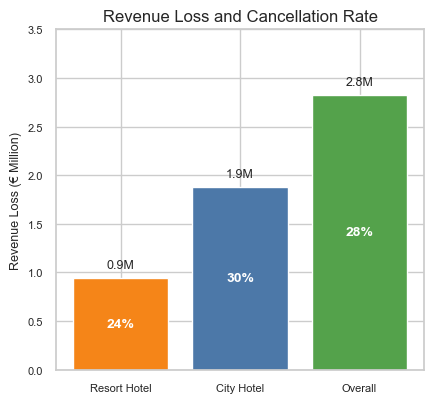

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_df = final_summary.sort_values(by="revenue_loss", ascending=True).reset_index(drop=True)
color_map = {"Overall": OVERALL_COLOR, "City Hotel": CITY_COLOR, "Resort Hotel": RESORT_COLOR}
colors = [color_map[h] for h in plot_df["hotel"]]

fig, ax = plt.subplots(figsize=(4.5, 4.2))
bars = ax.bar(plot_df["hotel"], plot_df["revenue_loss"], color=colors)

ax.set_title("Revenue Loss and Cancellation Rate")
ax.set_ylabel("Revenue Loss (€ Million)")
ax.set_ylim(0, 3_500_000)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:.1f}"))

for idx, row in enumerate(plot_df.itertuples()):
    x = idx
    y = row.revenue_loss
    ax.text(x, y + 100000, f"{y/1e6:.1f}M", ha="center", fontsize=9)
    ax.text(x, y * 0.5, f"{row.cancellation_rate * 100:.0f}%", ha="center", va="center", color="white", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()





Cancellations impact revenue through both direct and indirect channels.

Directly, cancellations reduce revenue realization, as confirmed bookings are not converted into actual stays. Indirectly, high cancellation rates introduce uncertainty into demand forecasting, affecting both occupancy and pricing strategies. In particular, last-minute cancellations may result in unfilled inventory or require reactive discounting, reducing overall revenue optimization.

The overall cancellation rate is 27.9%, resulting in an estimated revenue loss of €2.8M across 86K bookings, indicating a substantial business impact.

City Hotel exhibits a higher cancellation rate (30%) compared to Resort Hotel (24%) and contributes the majority of total revenue loss (€1.9M).

Given both its higher cancellation risk and greater financial impact, City Hotel should be prioritized for targeted cancellation reduction strategies.

### Question 2. Which Factors Are Associated with Higher Cancellation Rates?

We test five driver groups: lead time, deposit type, market segment, distribution channel, and loyalty.


In [20]:
def cancellation_summary(data, group_col):
    summary = (
        data.groupby(group_col, dropna=False, observed=False)
        .agg(
            cancellation_rate=("is_canceled", "mean"),
            bookings=("is_canceled", "size")
        )
        .reset_index()
    )
    return summary.sort_values("cancellation_rate", ascending=False)

lead_time_summary = (
    df_clean.groupby(["hotel", "lead_time_group"], observed=False)
    .agg(
        bookings=("is_canceled", "size"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        cancellation_revenue=("revenue_loss", "sum")
    )
    .reset_index()
)
lead_time_summary["cancellation_share"] = (
    lead_time_summary["canceled_bookings"]
    / lead_time_summary.groupby("hotel")["canceled_bookings"].transform("sum")
)
lead_time_summary["revenue_loss_share"] = (
    lead_time_summary["cancellation_revenue"]
    / lead_time_summary.groupby("hotel")["cancellation_revenue"].transform("sum")
)

lead_time_overall = (
    df_clean.groupby("lead_time_group", observed=False)
    .agg(
        bookings=("is_canceled", "size"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        cancellation_revenue=("revenue_loss", "sum")
    )
    .reset_index()
)
lead_time_overall["hotel"] = "Overall"
lead_time_overall["cancellation_share"] = (
    lead_time_overall["canceled_bookings"]
    / lead_time_overall["canceled_bookings"].sum()
)
lead_time_overall["revenue_loss_share"] = (
    lead_time_overall["cancellation_revenue"]
    / lead_time_overall["cancellation_revenue"].sum()
)

lead_time_summary = pd.concat([lead_time_summary, lead_time_overall], ignore_index=True)
lead_time_summary = lead_time_summary[[
    "hotel", "lead_time_group", "bookings", "canceled_bookings",
    "cancellation_rate", "cancellation_share", "cancellation_revenue", "revenue_loss_share"
]]

deposit_driver_summary = cancellation_summary(df_clean, "deposit_type")

deposit_by_hotel = (
    df_clean.groupby(["hotel", "deposit_type"], observed=False)
    .agg(
        bookings=("is_canceled", "size"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        cancellation_revenue=("revenue_loss", "sum")
    )
    .reset_index()
)
deposit_by_hotel["cancellation_share"] = (
    deposit_by_hotel["canceled_bookings"]
    / deposit_by_hotel.groupby("hotel")["canceled_bookings"].transform("sum")
)
deposit_by_hotel["revenue_loss_share"] = (
    deposit_by_hotel["cancellation_revenue"]
    / deposit_by_hotel.groupby("hotel")["cancellation_revenue"].transform("sum")
)

deposit_overall = (
    df_clean.groupby("deposit_type", observed=False)
    .agg(
        bookings=("is_canceled", "size"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        cancellation_revenue=("revenue_loss", "sum")
    )
    .reset_index()
)
deposit_overall["hotel"] = "Overall"
deposit_overall["cancellation_share"] = deposit_overall["canceled_bookings"] / deposit_overall["canceled_bookings"].sum()
deposit_overall["revenue_loss_share"] = deposit_overall["cancellation_revenue"] / deposit_overall["cancellation_revenue"].sum()

deposit_summary = pd.concat([deposit_by_hotel, deposit_overall], ignore_index=True)
deposit_summary = deposit_summary[[
    "hotel", "deposit_type", "bookings", "canceled_bookings",
    "cancellation_rate", "cancellation_share", "cancellation_revenue", "revenue_loss_share"
]]

#### 2.1 Lead Time


In [21]:
lead_time_summary

,hotel,lead_time_group,bookings,canceled_bookings,cancellation_rate,cancellation_share,cancellation_revenue,revenue_loss_share
0,City Hotel,0-7,9190,974,0.105985,0.061108,111310.56,0.059139
1,City Hotel,8-30,10378,2921,0.281461,0.183261,363144.49,0.192939
2,City Hotel,31-90,15046,5009,0.332912,0.314261,603776.00,0.320787
3,City Hotel,91-180,11512,4236,0.367964,0.265763,507633.37,0.269706
4,City Hotel,181+,6195,2799,0.451816,0.175607,296308.25,0.157429
5,Resort Hotel,0-7,8081,482,0.059646,0.061005,42921.98,0.045309
6,Resort Hotel,8-30,5676,1194,0.210359,0.151120,143701.73,0.151694
7,Resort Hotel,31-90,7462,2245,0.300858,0.284141,272524.52,0.287682
8,Resort Hotel,91-180,6608,2131,0.322488,0.269713,277633.66,0.293075
9,Resort Hotel,181+,5438,1849,0.340015,0.234021,210529.18,0.222239


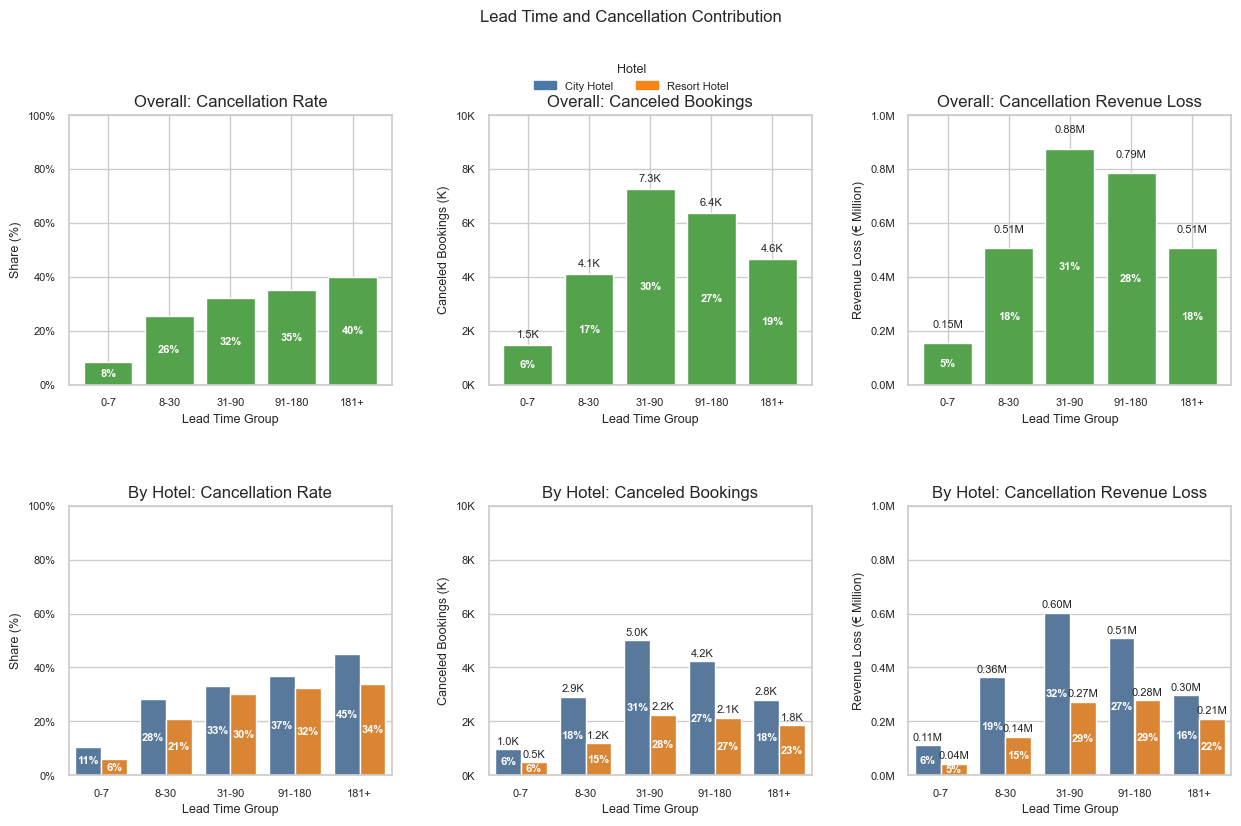

In [22]:
overall_df = lead_time_summary[lead_time_summary["hotel"] == "Overall"].copy()
overall_df = overall_df.set_index("lead_time_group").reindex(LEAD_TIME_LABELS).reset_index()
hotel_df = lead_time_summary[lead_time_summary["hotel"].isin(HOTEL_ORDER)].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 8.8))
fig.subplots_adjust(top=0.86, hspace=0.45, wspace=0.30)

bars_rate = axes[0, 0].bar(overall_df["lead_time_group"].astype(str), overall_df["cancellation_rate"], color=OVERALL_COLOR)
axes[0, 0].set_title("Overall: Cancellation Rate")
axes[0, 0].set_xlabel("Lead Time Group")
axes[0, 0].set_ylabel("Share (%)")
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))
for bar, value in zip(bars_rate, overall_df["cancellation_rate"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    axes[0, 0].text(x, y * 0.5 if y > 0 else 0.03, f"{value:.0%}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")

overall_df["canceled_bookings_k"] = overall_df["canceled_bookings"] / 1000
bars_cancel = axes[0, 1].bar(overall_df["lead_time_group"].astype(str), overall_df["canceled_bookings_k"], color=OVERALL_COLOR)
axes[0, 1].set_title("Overall: Canceled Bookings")
axes[0, 1].set_xlabel("Lead Time Group")
axes[0, 1].set_ylabel("Canceled Bookings (K)")
axes[0, 1].set_ylim(0, 10)
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0f}K"))
for bar, share, value in zip(bars_cancel, overall_df["cancellation_share"], overall_df["canceled_bookings_k"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    axes[0, 1].text(x, min(y + 0.2, 9.8), f"{value:.1f}K", ha="center", va="bottom", fontsize=8)
    axes[0, 1].text(x, y * 0.5 if y > 0 else 0.2, f"{share:.0%}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")

overall_df["cancellation_revenue_m"] = overall_df["cancellation_revenue"] / 1e6
bars_rev = axes[0, 2].bar(overall_df["lead_time_group"].astype(str), overall_df["cancellation_revenue_m"], color=OVERALL_COLOR)
axes[0, 2].set_title("Overall: Cancellation Revenue Loss")
axes[0, 2].set_xlabel("Lead Time Group")
axes[0, 2].set_ylabel("Revenue Loss (€ Million)")
axes[0, 2].set_ylim(0, 1.0)
axes[0, 2].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.1f}M"))
for bar, share, value in zip(bars_rev, overall_df["revenue_loss_share"], overall_df["cancellation_revenue_m"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    axes[0, 2].text(x, min(y + 0.05, 0.95), f"{value:.2f}M", ha="center", va="bottom", fontsize=8)
    axes[0, 2].text(x, y * 0.5 if y > 0 else 0.05, f"{share:.0%}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")

sns.barplot(data=hotel_df, x="lead_time_group", y="cancellation_rate", hue="hotel", order=LEAD_TIME_LABELS, hue_order=HOTEL_ORDER, palette=HOTEL_PALETTE, ax=axes[1, 0])
axes[1, 0].set_title("By Hotel: Cancellation Rate")
axes[1, 0].set_xlabel("Lead Time Group")
axes[1, 0].set_ylabel("Share (%)")
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))
for container in axes[1, 0].containers:
    labels = [f"{bar.get_height():.0%}" if bar.get_height() > 0 else "" for bar in container]
    axes[1, 0].bar_label(container, labels=labels, label_type="center", color="white", fontsize=8, fontweight="bold")
if axes[1, 0].legend_ is not None:
    axes[1, 0].legend_.remove()

hotel_plot = hotel_df.copy()
hotel_plot["canceled_bookings_k"] = hotel_plot["canceled_bookings"] / 1000
sns.barplot(data=hotel_plot, x="lead_time_group", y="canceled_bookings_k", hue="hotel", order=LEAD_TIME_LABELS, hue_order=HOTEL_ORDER, palette=HOTEL_PALETTE, ax=axes[1, 1])
axes[1, 1].set_title("By Hotel: Canceled Bookings")
axes[1, 1].set_xlabel("Lead Time Group")
axes[1, 1].set_ylabel("Canceled Bookings (K)")
axes[1, 1].set_ylim(0, 10)
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0f}K"))
for container, hotel_name in zip(axes[1, 1].containers, HOTEL_ORDER):
    vals = hotel_plot[hotel_plot["hotel"] == hotel_name].set_index("lead_time_group").reindex(LEAD_TIME_LABELS)
    center_labels = [f"{v:.0%}" if pd.notna(v) else "" for v in vals["cancellation_share"]]
    top_labels = [f"{v:.1f}K" if pd.notna(v) else "" for v in vals["canceled_bookings_k"]]
    axes[1, 1].bar_label(container, labels=center_labels, label_type="center", color="white", fontsize=8, fontweight="bold")
    axes[1, 1].bar_label(container, labels=top_labels, padding=2, fontsize=8)
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()

hotel_plot["cancellation_revenue_m"] = hotel_plot["cancellation_revenue"] / 1e6
sns.barplot(data=hotel_plot, x="lead_time_group", y="cancellation_revenue_m", hue="hotel", order=LEAD_TIME_LABELS, hue_order=HOTEL_ORDER, palette=HOTEL_PALETTE, ax=axes[1, 2])
axes[1, 2].set_title("By Hotel: Cancellation Revenue Loss")
axes[1, 2].set_xlabel("Lead Time Group")
axes[1, 2].set_ylabel("Revenue Loss (€ Million)")
axes[1, 2].set_ylim(0, 1.0)
axes[1, 2].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.1f}M"))
for container, hotel_name in zip(axes[1, 2].containers, HOTEL_ORDER):
    vals = hotel_plot[hotel_plot["hotel"] == hotel_name].set_index("lead_time_group").reindex(LEAD_TIME_LABELS)
    center_labels = [f"{v:.0%}" if pd.notna(v) else "" for v in vals["revenue_loss_share"]]
    top_labels = [f"{v:.2f}M" if pd.notna(v) else "" for v in vals["cancellation_revenue_m"]]
    axes[1, 2].bar_label(container, labels=center_labels, label_type="center", color="white", fontsize=8, fontweight="bold")
    axes[1, 2].bar_label(container, labels=top_labels, padding=2, fontsize=8)
if axes[1, 2].legend_ is not None:
    axes[1, 2].legend_.remove()

handles = [plt.Rectangle((0, 0), 1, 1, color=HOTEL_PALETTE[h]) for h in HOTEL_ORDER]
fig.legend(handles, HOTEL_ORDER, title="Hotel", loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.93))
fig.suptitle("Lead Time and Cancellation Contribution", y=0.98, fontsize=12)
plt.show()

Lead time shows a clear and interpretable relationship with cancellation behavior.

Cancellation risk increases consistently with longer booking lead times, indicating that bookings made further in advance are more susceptible to uncertainty and change. For example, bookings made within one week have a cancellation rate of only 8%, while bookings made more than six months in advance reach approximately 40%. This pattern is consistent across both hotel types, though City Hotel exhibits a higher sensitivity, with cancellation rates rising from 11% (within one week) to 45% (over six months), compared to a more stable ~30% level for Resort Hotel.

From a volume and revenue perspective, the distribution of cancellations is highly concentrated in mid-range lead times. Bookings made 30–180 days in advance account for nearly 60% of all cancellations and contribute approximately €1.7M in revenue loss, making this segment the primary driver of overall impact. In contrast, short lead-time bookings (<7 days) contribute only 6% of cancellations and a relatively small share of revenue loss (~€0.15M), despite their low cancellation risk.

Combining behavioral risk and business impact, bookings with lead times between 30 and 180 days represent the highest-priority segment for intervention. While very long lead times (>180 days) exhibit the highest cancellation rates, their lower volume limits their overall impact. Short lead times, despite their stability, contribute minimally to revenue loss and therefore represent the lowest priority for optimization.

Overall, City Hotel contributes disproportionately to cancellation-related revenue loss due to both higher cancellation rates and larger booking volumes, reinforcing its priority for targeted strategies.

##### Extended EDA: Lead Time and ADR Under Demand Conditions

To reduce cross-hotel noise, we analyze the ADR and lead time relationship separately for `City Hotel` and `Resort Hotel`.

For each hotel, we use three complementary views:
- Monthly boxplots compare canceled and not canceled orders within the same arrival month and lead time group.
- A line chart summarizes median ADR across all bookings, canceled bookings, and not canceled bookings.
- A heatmap shows where canceled bookings are concentrated, with average ADR shown inside each cell.



In [23]:
palette = HOTEL_PALETTE.copy()
light_palette = HOTEL_LIGHT_PALETTE.copy()
neutral_color = NEUTRAL_COLOR
min_heatmap_samples = MIN_HEATMAP_SAMPLES

df_clean["arrival_month_abbr"] = pd.Categorical(
    df_clean["arrival_date_month"].map(MONTH_ABBR_MAP),
    categories=MONTH_LABELS,
    ordered=True
)

###### City Hotel: ADR by Month, Lead Time, and Cancellation Status

This view compares canceled and not canceled bookings inside each arrival month.

By keeping the month fixed and splitting orders by cancellation status, we can see whether canceled bookings systematically sit at a different ADR level from retained bookings under the same seasonal demand condition.



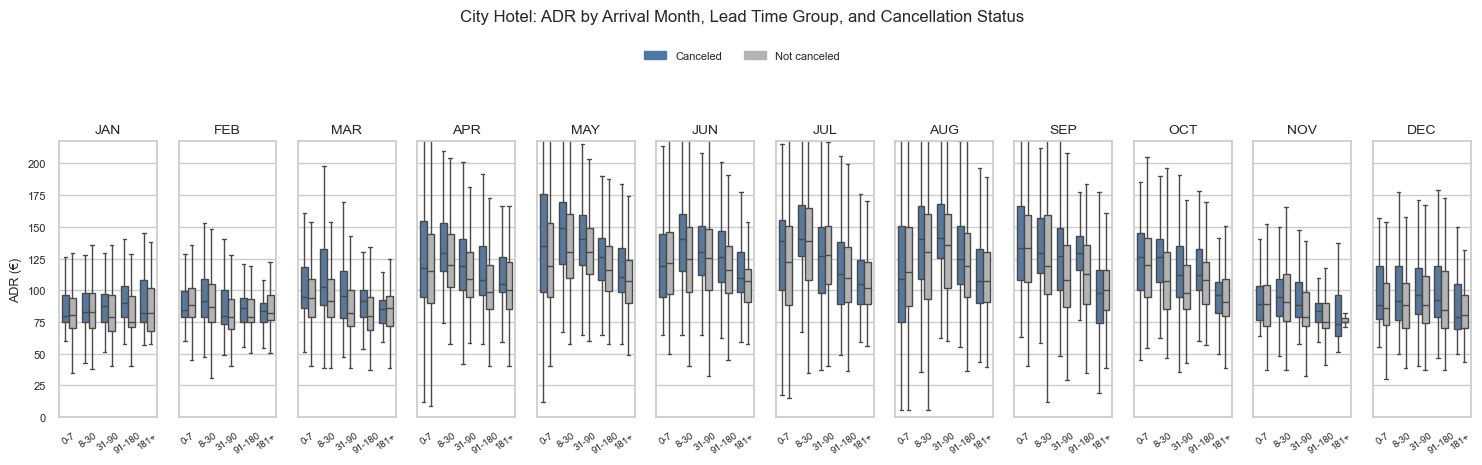

In [24]:
city_df = df_clean[df_clean["hotel"] == "City Hotel"].copy()
city_ymax = city_df["adr"].quantile(0.98)
city_df["cancel_status"] = city_df["is_canceled"].map({1: "Canceled", 0: "Not canceled"})

fig, axes = plt.subplots(1, 12, figsize=(15, 4), sharey=True)
for ax, month in zip(axes, MONTH_LABELS):
    month_df = city_df[city_df["arrival_month_abbr"] == month]
    sns.boxplot(
        data=month_df,
        x="lead_time_group",
        y="adr",
        hue="cancel_status",
        order=LEAD_TIME_LABELS,
        hue_order=["Canceled", "Not canceled"],
        palette={"Canceled": HOTEL_PALETTE["City Hotel"], "Not canceled": NEUTRAL_COLOR},
        showfliers=False,
        width=0.7,
        ax=ax
    )
    ax.set_title(month, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylim(0, city_ymax)
    ax.tick_params(axis="x", rotation=35, labelsize=7)
    if ax.legend_ is not None:
        ax.legend_.remove()

axes[0].set_ylabel("ADR (€)")
for ax in axes[1:]:
    ax.set_ylabel("")
    ax.yaxis.label.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=HOTEL_PALETTE["City Hotel"]),
    plt.Rectangle((0, 0), 1, 1, color=NEUTRAL_COLOR)
]
fig.legend(handles, ["Canceled", "Not canceled"], frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.08))
fig.suptitle("City Hotel: ADR by Arrival Month, Lead Time Group, and Cancellation Status", y=1.16, fontsize=12)
plt.tight_layout()
plt.show()

###### City Hotel: Overall ADR Trend and Pricing Structure

The line chart compares median ADR across lead time groups for all bookings, canceled bookings, and not canceled bookings, with the IQR band showing variability around each series.

The heatmap then shows where canceled bookings are concentrated across arrival month and lead time group. Color represents canceled booking count, while each cell annotation shows the average ADR of canceled bookings.






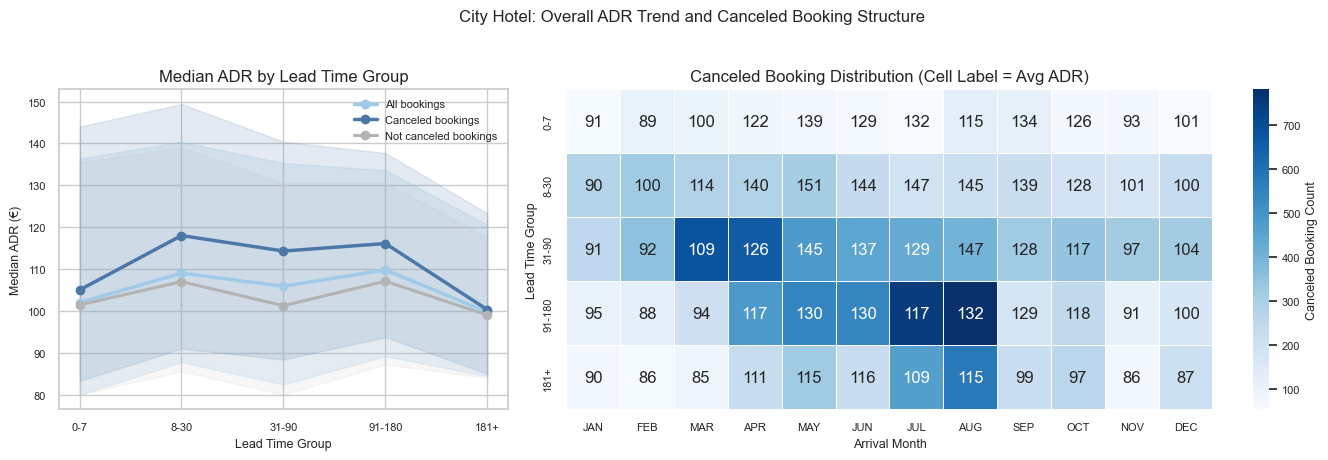

In [26]:
city_df = df_clean[df_clean["hotel"] == "City Hotel"].copy()
city_canceled_df = city_df[city_df["is_canceled"] == 1].copy()
city_kept_df = city_df[city_df["is_canceled"] == 0].copy()

city_trend_all = (
    city_df.groupby("lead_time_group", observed=False)["adr"]
    .agg(
        median_adr="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(LEAD_TIME_LABELS)
    .reset_index()
)
city_trend_cxl = (
    city_canceled_df.groupby("lead_time_group", observed=False)["adr"]
    .agg(
        median_adr="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(LEAD_TIME_LABELS)
    .reset_index()
)
city_trend_kept = (
    city_kept_df.groupby("lead_time_group", observed=False)["adr"]
    .agg(
        median_adr="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(LEAD_TIME_LABELS)
    .reset_index()
)

city_cxl_counts = (
    city_canceled_df.groupby(["lead_time_group", "arrival_month_abbr"], observed=False)["is_canceled"]
    .size()
    .unstack()
    .reindex(index=LEAD_TIME_LABELS, columns=MONTH_LABELS)
)
city_cxl_adr = (
    city_canceled_df.groupby(["lead_time_group", "arrival_month_abbr"], observed=False)["adr"]
    .mean()
    .unstack()
    .reindex(index=LEAD_TIME_LABELS, columns=MONTH_LABELS)
)
city_annotation = city_cxl_adr.copy().astype(object)
for row in city_annotation.index:
    for col in city_annotation.columns:
        value = city_cxl_adr.loc[row, col]
        if pd.isna(value):
            city_annotation.loc[row, col] = ""
        else:
            city_annotation.loc[row, col] = f"{value:.0f}"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.8]})
x_positions = np.arange(len(LEAD_TIME_LABELS))

axes[0].plot(x_positions, city_trend_all["median_adr"], marker="o", linewidth=2.5, color=HOTEL_LIGHT_PALETTE["City Hotel"], label="All bookings")
axes[0].fill_between(x_positions, city_trend_all["q1"], city_trend_all["q3"], color=HOTEL_LIGHT_PALETTE["City Hotel"], alpha=0.22)
axes[0].plot(x_positions, city_trend_cxl["median_adr"], marker="o", linewidth=2.5, color=HOTEL_PALETTE["City Hotel"], label="Canceled bookings")
axes[0].fill_between(x_positions, city_trend_cxl["q1"], city_trend_cxl["q3"], color=HOTEL_PALETTE["City Hotel"], alpha=0.15)
axes[0].plot(x_positions, city_trend_kept["median_adr"], marker="o", linewidth=2.2, color=NEUTRAL_COLOR, label="Not canceled bookings")
axes[0].fill_between(x_positions, city_trend_kept["q1"], city_trend_kept["q3"], color=NEUTRAL_COLOR, alpha=0.10)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(LEAD_TIME_LABELS)
axes[0].set_title("Median ADR by Lead Time Group")
axes[0].set_xlabel("Lead Time Group")
axes[0].set_ylabel("Median ADR (€)")
axes[0].legend(frameon=False, fontsize=8)

sns.heatmap(
    city_cxl_counts,
    annot=city_annotation.values,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Canceled Booking Count"},
    ax=axes[1]
)
axes[1].set_title("Canceled Booking Distribution (Cell Label = Avg ADR)")
axes[1].set_xlabel("Arrival Month")
axes[1].set_ylabel("Lead Time Group")

fig.suptitle("City Hotel: Overall ADR Trend and Canceled Booking Structure", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


In [27]:
months = ["March", "April", "May", "June", "July", "August"]

city_cxl = df_clean[
    (df_clean["hotel"] == "City Hotel") &
    (df_clean["is_canceled"] == 1)
].copy()

segment = city_cxl[
    (city_cxl["arrival_date_month"].isin(months)) &
    (city_cxl["lead_time_group"] == "31-90")
].copy()

booking_share = len(segment) / len(city_cxl)
revenue_share = segment["revenue_loss"].sum() / city_cxl["revenue_loss"].sum()

print("Canceled bookings:", len(segment))
print("Booking share:", f"{booking_share:.1%}")
print("Lost revenue:", f"€{segment['revenue_loss'].sum():,.2f}")
print("Revenue share:", f"{revenue_share:.1%}")


Canceled bookings: 3107
Booking share: 19.5%
Lost revenue: €403,749.74
Revenue share: 21.5%


###### Resort Hotel: ADR by Month, Lead Time, and Cancellation Status

This view compares canceled and not canceled bookings inside each arrival month.

By keeping the month fixed and splitting orders by cancellation status, we can see whether canceled bookings systematically sit at a different ADR level from retained bookings under the same seasonal demand condition.




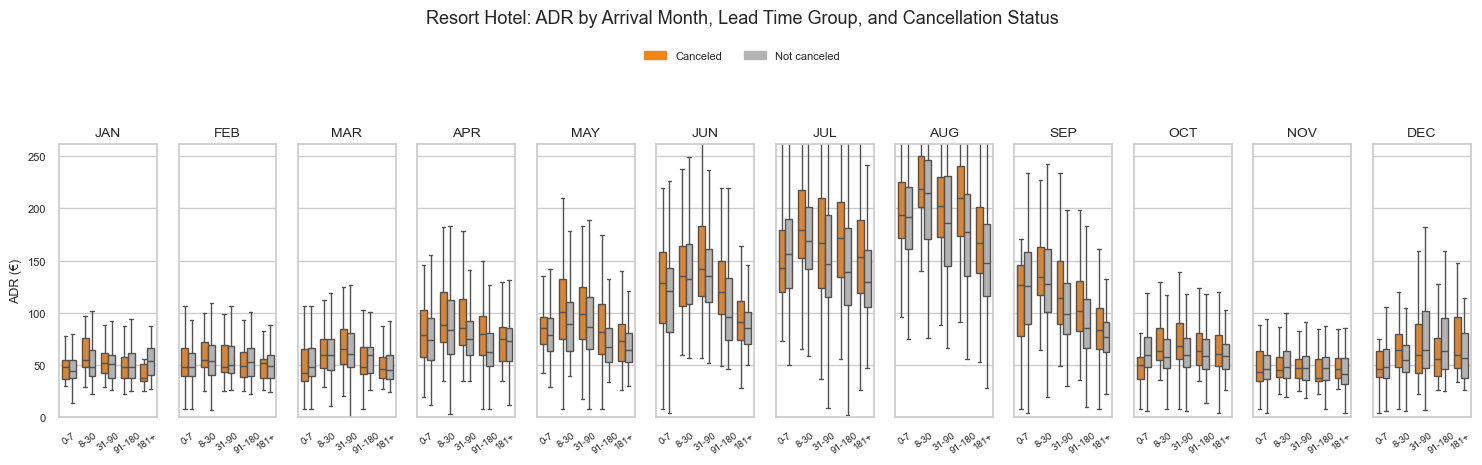

In [28]:
resort_df = df_clean[df_clean["hotel"] == "Resort Hotel"].copy()
resort_ymax = resort_df["adr"].quantile(0.98)
resort_df["cancel_status"] = resort_df["is_canceled"].map({1: "Canceled", 0: "Not canceled"})

fig, axes = plt.subplots(1, 12, figsize=(15, 4), sharey=True)
for ax, month in zip(axes, MONTH_LABELS):
    month_df = resort_df[resort_df["arrival_month_abbr"] == month]
    sns.boxplot(
        data=month_df,
        x="lead_time_group",
        y="adr",
        hue="cancel_status",
        order=LEAD_TIME_LABELS,
        hue_order=["Canceled", "Not canceled"],
        palette={"Canceled": HOTEL_PALETTE["Resort Hotel"], "Not canceled": NEUTRAL_COLOR},
        showfliers=False,
        width=0.7,
        ax=ax
    )
    ax.set_title(month, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylim(0, resort_ymax)
    ax.tick_params(axis="x", rotation=35, labelsize=7)
    if ax.legend_ is not None:
        ax.legend_.remove()

axes[0].set_ylabel("ADR (€)")
for ax in axes[1:]:
    ax.set_ylabel("")
    ax.yaxis.label.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=HOTEL_PALETTE["Resort Hotel"]),
    plt.Rectangle((0, 0), 1, 1, color=NEUTRAL_COLOR)
]
fig.legend(handles, ["Canceled", "Not canceled"], frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Resort Hotel: ADR by Arrival Month, Lead Time Group, and Cancellation Status", y=1.16, fontsize=13)
plt.tight_layout()
plt.show()


###### Resort Hotel: Overall ADR Trend and Pricing Structure

The line chart compares median ADR across lead time groups for all bookings, canceled bookings, and not canceled bookings, with the IQR band showing variability around each series.

The heatmap then shows where canceled bookings are concentrated across arrival month and lead time group. Color represents canceled booking count, while each cell annotation shows the average ADR of canceled bookings.







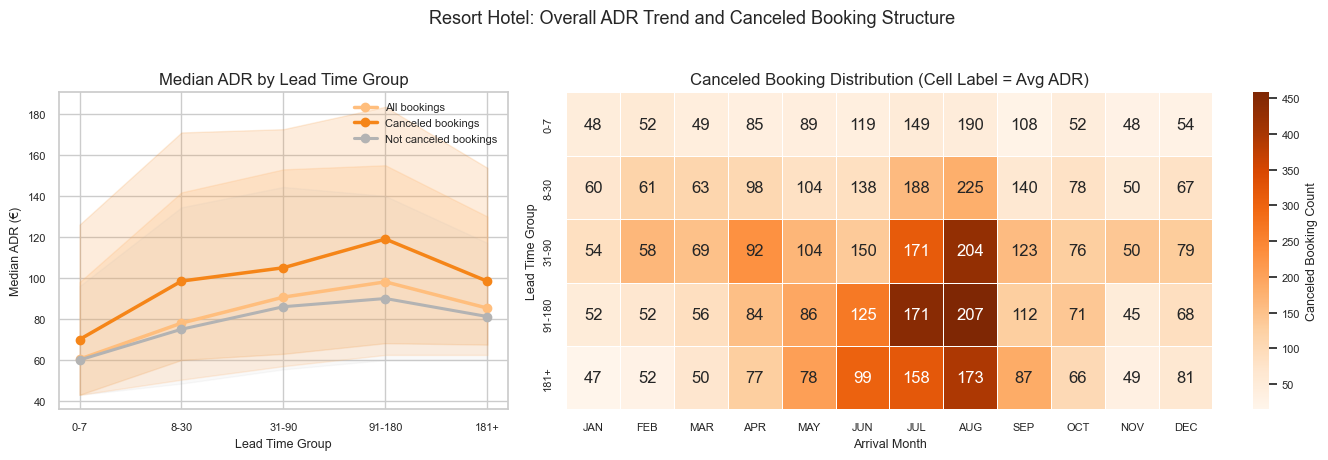

In [29]:
resort_df = df_clean[df_clean["hotel"] == "Resort Hotel"].copy()
resort_canceled_df = resort_df[resort_df["is_canceled"] == 1].copy()

resort_trend_all = (
    resort_df.groupby("lead_time_group", observed=False)["adr"]
    .agg(
        median_adr="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(LEAD_TIME_LABELS)
    .reset_index()
)
resort_trend_cxl = (
    resort_canceled_df.groupby("lead_time_group", observed=False)["adr"]
    .agg(
        median_adr="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(LEAD_TIME_LABELS)
    .reset_index()
)
resort_kept_df = resort_df[resort_df["is_canceled"] == 0].copy()
resort_trend_kept = (
    resort_kept_df.groupby("lead_time_group", observed=False)["adr"]
    .agg(
        median_adr="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    )
    .reindex(LEAD_TIME_LABELS)
    .reset_index()
)

resort_cxl_counts = (
    resort_canceled_df.groupby(["lead_time_group", "arrival_month_abbr"], observed=False)["is_canceled"]
    .size()
    .unstack()
    .reindex(index=LEAD_TIME_LABELS, columns=MONTH_LABELS)
)
resort_cxl_adr = (
    resort_canceled_df.groupby(["lead_time_group", "arrival_month_abbr"], observed=False)["adr"]
    .mean()
    .unstack()
    .reindex(index=LEAD_TIME_LABELS, columns=MONTH_LABELS)
)
resort_annotation = resort_cxl_adr.copy().astype(object)
for row in resort_annotation.index:
    for col in resort_annotation.columns:
        value = resort_cxl_adr.loc[row, col]
        if pd.isna(value):
            resort_annotation.loc[row, col] = ""
        else:
            resort_annotation.loc[row, col] = f"{value:.0f}"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.8]})
x_positions = np.arange(len(LEAD_TIME_LABELS))

axes[0].plot(x_positions, resort_trend_all["median_adr"], marker="o", linewidth=2.5, color=HOTEL_LIGHT_PALETTE["Resort Hotel"], label="All bookings")
axes[0].fill_between(x_positions, resort_trend_all["q1"], resort_trend_all["q3"], color=HOTEL_LIGHT_PALETTE["Resort Hotel"], alpha=0.22)
axes[0].plot(x_positions, resort_trend_cxl["median_adr"], marker="o", linewidth=2.5, color=HOTEL_PALETTE["Resort Hotel"], label="Canceled bookings")
axes[0].fill_between(x_positions, resort_trend_cxl["q1"], resort_trend_cxl["q3"], color=HOTEL_PALETTE["Resort Hotel"], alpha=0.15)
axes[0].plot(x_positions, resort_trend_kept["median_adr"], marker="o", linewidth=2.2, color=NEUTRAL_COLOR, label="Not canceled bookings")
axes[0].fill_between(x_positions, resort_trend_kept["q1"], resort_trend_kept["q3"], color=NEUTRAL_COLOR, alpha=0.08)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(LEAD_TIME_LABELS)
axes[0].set_title("Median ADR by Lead Time Group")
axes[0].set_xlabel("Lead Time Group")
axes[0].set_ylabel("Median ADR (€)")
axes[0].legend(frameon=False, fontsize=8)

sns.heatmap(
    resort_cxl_counts,
    annot=resort_annotation.values,
    fmt="",
    cmap="Oranges",
    linewidths=0.5,
    cbar_kws={"label": "Canceled Booking Count"},
    ax=axes[1]
)
axes[1].set_title("Canceled Booking Distribution (Cell Label = Avg ADR)")
axes[1].set_xlabel("Arrival Month")
axes[1].set_ylabel("Lead Time Group")

fig.suptitle("Resort Hotel: Overall ADR Trend and Canceled Booking Structure", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


City hotel: Cancellation bookings are concentrated in March–August, primarily within 31–90 days lead time. 

- 3,107 cancellations
- Revenue loss: 0.4M
- Share: 19.5% (count) / 21.5% (value)

Resort Hotel: cancellation bookings are concentrated in June–August, primarily within lead time > 30 days.

- 3,068 cancellations
- Revenue loss: 0.5M
- Share: 38.8% (count) / 54.4% (value)

**Key Takeaway**
Resort cancellations are disproportionately driven by high-value bookings, whereas City cancellations are more evenly distributed across booking values. This suggests fundamentally different cancellation dynamics between the two hotel types.


#### 2.2 Deposit Type


In [25]:
deposit_summary

,hotel,deposit_type,bookings,canceled_bookings,cancellation_rate,cancellation_share,cancellation_revenue,revenue_loss_share
0,City Hotel,No Deposit,51461,15108,0.293582,0.947864,1800001.58,0.956342
1,City Hotel,Non Refund,845,821,0.971598,0.051509,80817.79,0.042939
2,City Hotel,Refundable,15,10,0.666667,0.000627,1353.30,0.000719
3,Resort Hotel,No Deposit,32980,7723,0.234172,0.977471,935077.22,0.987086
4,Resort Hotel,Non Refund,193,162,0.839378,0.020504,10643.20,0.011235
5,Resort Hotel,Refundable,92,16,0.173913,0.002025,1590.65,0.001679
6,Overall,No Deposit,84441,22831,0.270378,0.957676,2735078.80,0.966635
7,Overall,Non Refund,1038,983,0.947013,0.041233,91460.99,0.032324
8,Overall,Refundable,107,26,0.242991,0.001091,2943.95,0.001040


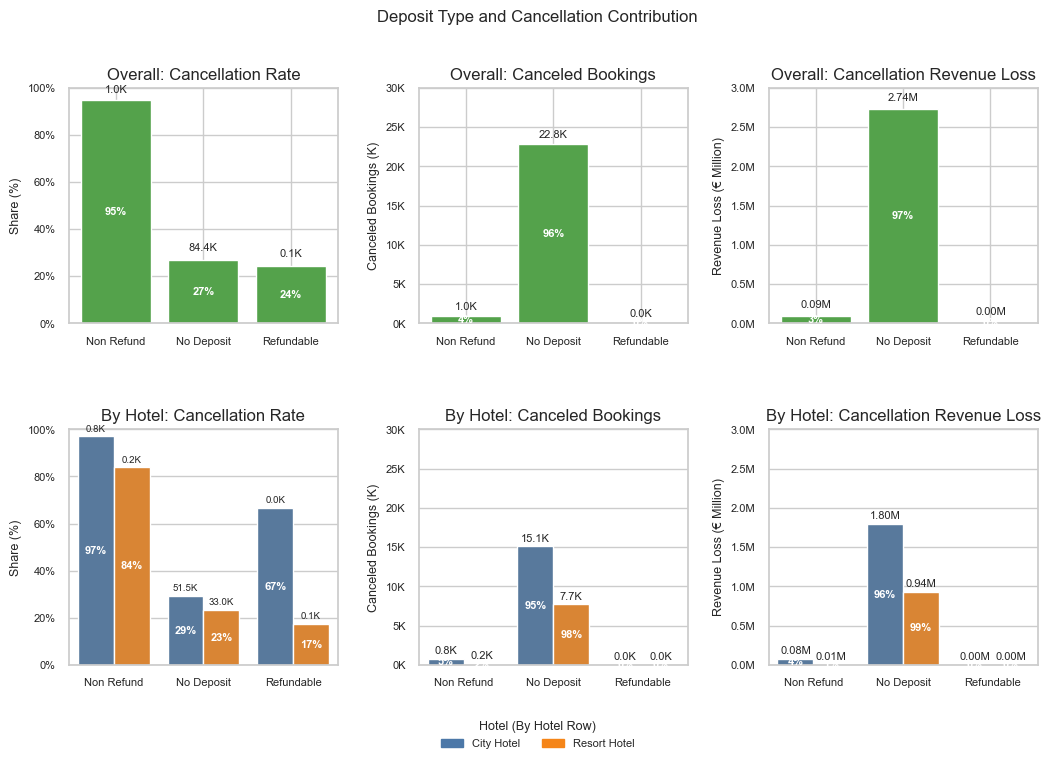

In [26]:
from matplotlib.ticker import FuncFormatter

hotel_order = ["City Hotel", "Resort Hotel"]
palette = {"City Hotel": CITY_COLOR, "Resort Hotel": RESORT_COLOR}
overall_df = deposit_summary[deposit_summary["hotel"] == "Overall"].copy()
hotel_df = deposit_summary[deposit_summary["hotel"].isin(hotel_order)].copy()
deposit_order = overall_df.sort_values("cancellation_rate", ascending=False)["deposit_type"].tolist()
overall_df = overall_df.set_index("deposit_type").reindex(deposit_order).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.8))
fig.subplots_adjust(top=0.88, bottom=0.14, hspace=0.45, wspace=0.30)

bars_rate = axes[0, 0].bar(overall_df["deposit_type"].astype(str), overall_df["cancellation_rate"], color=OVERALL_COLOR)
axes[0, 0].set_title("Overall: Cancellation Rate")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Share (%)")
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))
for bar, value, bookings in zip(bars_rate, overall_df["cancellation_rate"], overall_df["bookings"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    axes[0, 0].text(x, y * 0.5 if y > 0 else 0.03, f"{value:.0%}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")
    axes[0, 0].text(x, min(y + 0.03, 0.97), f"{bookings/1000:.1f}K", ha="center", va="bottom", fontsize=8)

overall_df["canceled_bookings_k"] = overall_df["canceled_bookings"] / 1000
bars_cancel = axes[0, 1].bar(overall_df["deposit_type"].astype(str), overall_df["canceled_bookings_k"], color=OVERALL_COLOR)
axes[0, 1].set_title("Overall: Canceled Bookings")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Canceled Bookings (K)")
axes[0, 1].set_ylim(0, 30)
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0f}K"))
for bar, share, value in zip(bars_cancel, overall_df["cancellation_share"], overall_df["canceled_bookings_k"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    axes[0, 1].text(x, min(y + 0.5, 29.5), f"{value:.1f}K", ha="center", va="bottom", fontsize=8)
    axes[0, 1].text(x, y * 0.5 if y > 0 else 0.3, f"{share:.0%}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")

overall_df["cancellation_revenue_m"] = overall_df["cancellation_revenue"] / 1e6
bars_rev = axes[0, 2].bar(overall_df["deposit_type"].astype(str), overall_df["cancellation_revenue_m"], color=OVERALL_COLOR)
axes[0, 2].set_title("Overall: Cancellation Revenue Loss")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("Revenue Loss (€ Million)")
axes[0, 2].set_ylim(0, 3.0)
axes[0, 2].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.1f}M"))
for bar, share, value in zip(bars_rev, overall_df["revenue_loss_share"], overall_df["cancellation_revenue_m"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    axes[0, 2].text(x, min(y + 0.08, 2.9), f"{value:.2f}M", ha="center", va="bottom", fontsize=8)
    axes[0, 2].text(x, y * 0.5 if y > 0 else 0.05, f"{share:.0%}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")

sns.barplot(data=hotel_df, x="deposit_type", y="cancellation_rate", hue="hotel", order=deposit_order, hue_order=hotel_order, palette=palette, ax=axes[1, 0])
axes[1, 0].set_title("By Hotel: Cancellation Rate")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Share (%)")
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))
for container, hotel_name in zip(axes[1, 0].containers, hotel_order):
    labels = [f"{bar.get_height():.0%}" if bar.get_height() > 0 else "" for bar in container]
    axes[1, 0].bar_label(container, labels=labels, label_type="center", color="white", fontsize=8, fontweight="bold")
    vals = hotel_df[hotel_df["hotel"] == hotel_name].set_index("deposit_type").reindex(deposit_order)
    top_labels = [f"{v/1000:.1f}K" if pd.notna(v) else "" for v in vals["bookings"]]
    axes[1, 0].bar_label(container, labels=top_labels, padding=2, fontsize=7)
if axes[1, 0].legend_ is not None:
    axes[1, 0].legend_.remove()

hotel_plot = hotel_df.copy()
hotel_plot["canceled_bookings_k"] = hotel_plot["canceled_bookings"] / 1000
sns.barplot(data=hotel_plot, x="deposit_type", y="canceled_bookings_k", hue="hotel", order=deposit_order, hue_order=hotel_order, palette=palette, ax=axes[1, 1])
axes[1, 1].set_title("By Hotel: Canceled Bookings")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Canceled Bookings (K)")
axes[1, 1].set_ylim(0, 30)
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0f}K"))
for container, hotel_name in zip(axes[1, 1].containers, hotel_order):
    vals = hotel_plot[hotel_plot["hotel"] == hotel_name].set_index("deposit_type").reindex(deposit_order)
    center_labels = [f"{v:.0%}" if pd.notna(v) else "" for v in vals["cancellation_share"]]
    top_labels = [f"{v:.1f}K" if pd.notna(v) else "" for v in vals["canceled_bookings_k"]]
    axes[1, 1].bar_label(container, labels=center_labels, label_type="center", color="white", fontsize=8, fontweight="bold")
    axes[1, 1].bar_label(container, labels=top_labels, padding=2, fontsize=8)
if axes[1, 1].legend_ is not None:
    axes[1, 1].legend_.remove()

hotel_plot["cancellation_revenue_m"] = hotel_plot["cancellation_revenue"] / 1e6
sns.barplot(data=hotel_plot, x="deposit_type", y="cancellation_revenue_m", hue="hotel", order=deposit_order, hue_order=hotel_order, palette=palette, ax=axes[1, 2])
axes[1, 2].set_title("By Hotel: Cancellation Revenue Loss")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Revenue Loss (€ Million)")
axes[1, 2].set_ylim(0, 3.0)
axes[1, 2].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.1f}M"))
for container, hotel_name in zip(axes[1, 2].containers, hotel_order):
    vals = hotel_plot[hotel_plot["hotel"] == hotel_name].set_index("deposit_type").reindex(deposit_order)
    center_labels = [f"{v:.0%}" if pd.notna(v) else "" for v in vals["revenue_loss_share"]]
    top_labels = [f"{v:.2f}M" if pd.notna(v) else "" for v in vals["cancellation_revenue_m"]]
    axes[1, 2].bar_label(container, labels=center_labels, label_type="center", color="white", fontsize=8, fontweight="bold")
    axes[1, 2].bar_label(container, labels=top_labels, padding=2, fontsize=8)
if axes[1, 2].legend_ is not None:
    axes[1, 2].legend_.remove()

handles = [plt.Rectangle((0, 0), 1, 1, color=palette[h]) for h in hotel_order]
fig.legend(handles, hotel_order, title="Hotel (By Hotel Row)", loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.02))
fig.suptitle("Deposit Type and Cancellation Contribution", y=0.98, fontsize=12)
plt.show()




Deposit type shows a strong association with cancellation behavior and revenue impact.

Bookings without a deposit account for approximately 96% of all cancellations and contribute €2.7M in revenue loss, making them the dominant driver of overall cancellation impact. This pattern is particularly pronounced in Resort Hotel, where nearly all cancellations originate from no-deposit bookings.

In contrast, non-refundable bookings represent only a small share (~4%) of total bookings and exhibit minimal cancellation impact due to their strict policy.

These findings suggest that deposit policy is a key lever in managing cancellation risk. However, the observed relationship may also reflect underlying customer selection effects, where higher-risk bookings are more likely to be associated with flexible conditions.

Therefore, further analysis combining deposit type with lead time is recommended to better isolate behavioral patterns and support more targeted policy design.

##### Extended EDA: Deposit Type Within the Same Lead Time

To test whether deposit policy still matters after controlling for booking horizon, we compare deposit type across the same `lead_time_group` separately for each hotel.

In the heatmaps below:
- color intensity represents the number of canceled bookings
- cell labels show the cancellation rate



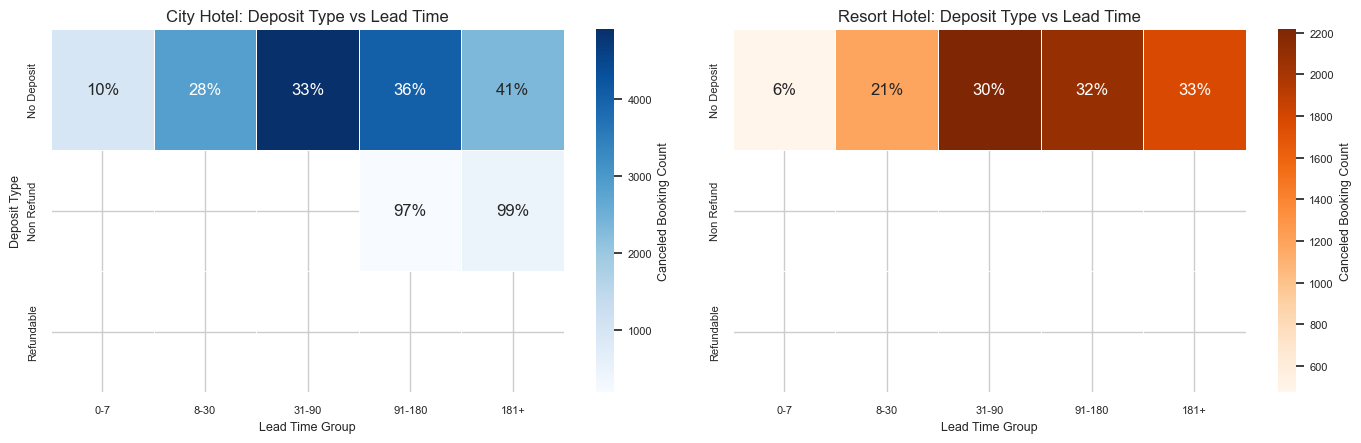

In [27]:
deposit_order = DEPOSIT_HEATMAP_ORDER
hotel_palette = HOTEL_HEATMAPS
min_samples = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

for ax, hotel_name in zip(axes, HOTEL_ORDER):
    hotel_df = df_clean[df_clean["hotel"] == hotel_name].copy()

    cancel_count = (
        hotel_df.groupby(["deposit_type", "lead_time_group"], observed=False)["is_canceled"]
        .sum()
        .unstack()
        .reindex(index=deposit_order, columns=LEAD_TIME_LABELS)
    )
    booking_count = (
        hotel_df.groupby(["deposit_type", "lead_time_group"], observed=False)["is_canceled"]
        .size()
        .unstack()
        .reindex(index=deposit_order, columns=LEAD_TIME_LABELS)
    )
    cancel_rate = (
        hotel_df.groupby(["deposit_type", "lead_time_group"], observed=False)["is_canceled"]
        .mean()
        .unstack()
        .reindex(index=deposit_order, columns=LEAD_TIME_LABELS)
    )

    count_filtered = cancel_count.copy()
    annotation = cancel_rate.copy().astype(object)

    for row in deposit_order:
        for col in LEAD_TIME_LABELS:
            n = booking_count.loc[row, col]
            rate = cancel_rate.loc[row, col]
            if pd.isna(rate):
                annotation.loc[row, col] = ""
            elif n < min_samples:
                count_filtered.loc[row, col] = np.nan
                annotation.loc[row, col] = "n<200"
            else:
                annotation.loc[row, col] = f"{rate:.0%}"

    sns.heatmap(
        count_filtered,
        annot=annotation.values,
        fmt="",
        cmap=hotel_palette[hotel_name],
        linewidths=0.5,
        cbar_kws={"label": "Canceled Booking Count"},
        ax=ax
    )
    ax.set_title(f"{hotel_name}: Deposit Type vs Lead Time")
    ax.set_xlabel("Lead Time Group")
    ax.set_ylabel("Deposit Type" if hotel_name == "City Hotel" else "")

plt.tight_layout()
plt.show()


##### Revenue-Weighted View: Deposit Type by Lead Time

To make the deposit analysis more business-focused, we also summarize each `deposit_type × lead_time_group` combination by lost revenue.

The table below adds average ADR, and the stacked bars show each segment's share of total lost revenue within each hotel. Each segment label displays both revenue share and revenue amount in `M`.



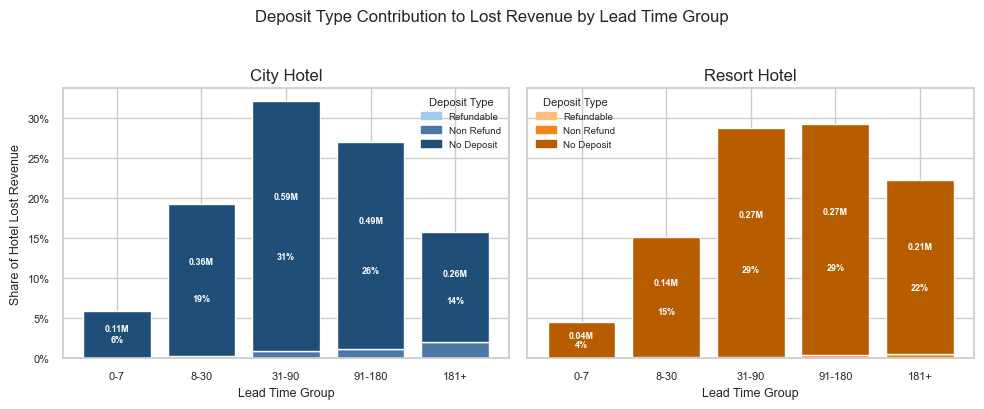

In [48]:
deposit_rev_view = df_clean[df_clean["is_canceled"] == 1].copy()

deposit_lead_revenue = (
    deposit_rev_view.groupby(["hotel", "lead_time_group", "deposit_type"], observed=False)
    .agg(
        canceled_bookings=("is_canceled", "size"),
        lost_revenue=("revenue_loss", "sum"),
        avg_adr=("adr", "mean")
    )
    .reset_index()
)

deposit_lead_revenue["revenue_share"] = (
    deposit_lead_revenue["lost_revenue"]
    / deposit_lead_revenue.groupby("hotel")["lost_revenue"].transform("sum")
)

deposit_lead_revenue["lost_revenue_m"] = deposit_lead_revenue["lost_revenue"] / 1e6
deposit_lead_revenue = deposit_lead_revenue.sort_values(["hotel", "lead_time_group", "deposit_type"])
deposit_lead_revenue

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, hotel_name, color_map, legend_loc in zip(
    axes,
    HOTEL_ORDER,
    [CITY_DEPOSIT_COLORS, RESORT_DEPOSIT_COLORS],
    ["upper right", "upper left"]
):
    plot_df = (
        deposit_lead_revenue[deposit_lead_revenue["hotel"] == hotel_name]
        .pivot(index="lead_time_group", columns="deposit_type", values="revenue_share")
        .reindex(LEAD_TIME_LABELS)
        .fillna(0)
    )
    amount_df = (
        deposit_lead_revenue[deposit_lead_revenue["hotel"] == hotel_name]
        .pivot(index="lead_time_group", columns="deposit_type", values="lost_revenue_m")
        .reindex(LEAD_TIME_LABELS)
        .fillna(0)
    )

    bottom = np.zeros(len(plot_df))
    for deposit_type in DEPOSIT_STACK_ORDER:
        values = plot_df[deposit_type].values if deposit_type in plot_df.columns else np.zeros(len(plot_df))
        amounts = amount_df[deposit_type].values if deposit_type in amount_df.columns else np.zeros(len(plot_df))
        bars = ax.bar(
            plot_df.index.astype(str),
            values,
            bottom=bottom,
            color=color_map[deposit_type],
            label=deposit_type
        )

        for bar, share, amount, btm in zip(bars, values, amounts, bottom):
            if share > 0.04:
                x = bar.get_x() + bar.get_width() / 2
                y_mid = btm + share / 2
                ax.text(x, y_mid + share * 0.12, f"{amount:.2f}M", ha="center", va="center", color="white", fontsize=6.5, fontweight="bold")
                ax.text(x, y_mid - share * 0.12, f"{share:.0%}", ha="center", va="center", color="white", fontsize=6.5, fontweight="bold")
        bottom += values

    ax.set_title(hotel_name, fontsize=12)
    ax.set_xlabel("Lead Time Group", fontsize=9)
    ax.set_ylabel("Share of Hotel Lost Revenue" if hotel_name == "City Hotel" else "", fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y:.0%}"))
    ax.legend(title="Deposit Type", frameon=False, loc=legend_loc)

plt.tight_layout()
plt.show()


Cancellations are overwhelmingly driven by no-deposit bookings, with risk increasing significantly as lead time extends.
No-deposit bookings account for the vast majority of cancellations (~96%)
Cancellation risk escalates with longer booking horizons, especially beyond 30 days
As a result, long lead-time bookings without deposit constraints are the primary source of revenue loss, with mid-to-long horizons (31+ days) contributing the largest share.

**Key Takeaway** Unsecured long lead-time bookings function as “free options” for customers, driving the majority of cancellation losses.

##### Extended EDA: Are Lost Revenues Concentrated in High-ADR No-Deposit Segments?

This view focuses only on canceled `No Deposit` bookings. We first trim ADR outliers using the IQR rule, then split the remaining bookings into `Low / Mid / High ADR` buckets using a `30% / 40% / 30%` split. The heatmap color shows total lost revenue, while each cell annotation shows the average ADR in that segment.


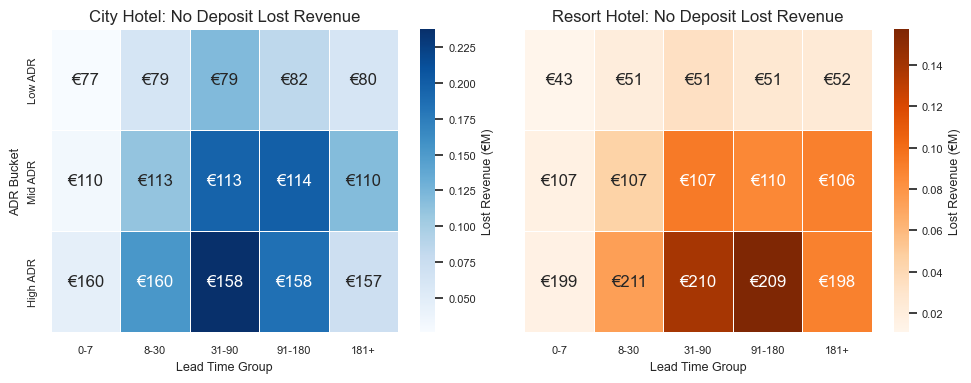

In [28]:
no_deposit_cxl = df_clean[
    (df_clean["deposit_type"] == "No Deposit")
    & (df_clean["is_canceled"] == 1)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, hotel_name, cmap in zip(
    axes,
    HOTEL_ORDER,
    ["Blues", "Oranges"]
):
    hotel_df = no_deposit_cxl[no_deposit_cxl["hotel"] == hotel_name].copy()

    q1 = hotel_df["adr"].quantile(0.25)
    q3 = hotel_df["adr"].quantile(0.75)
    iqr = q3 - q1
    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    hotel_df = hotel_df[(hotel_df["adr"] >= lower) & (hotel_df["adr"] <= upper)].copy()

    hotel_df["adr_bucket"] = pd.qcut(
        hotel_df["adr"],
        q=[0, 0.3, 0.7, 1],
        labels=ADR_BUCKET_LABELS,
        duplicates="drop"
    )

    lost_rev = (
        hotel_df.groupby(["adr_bucket", "lead_time_group"], observed=False)["revenue_loss"]
        .sum()
        .unstack()
        .reindex(index=ADR_BUCKET_LABELS, columns=LEAD_TIME_LABELS)
        / 1e6
    )

    avg_adr = (
        hotel_df.groupby(["adr_bucket", "lead_time_group"], observed=False)["adr"]
        .mean()
        .unstack()
        .reindex(index=ADR_BUCKET_LABELS, columns=LEAD_TIME_LABELS)
    )

    annotation = avg_adr.copy().astype(object)
    for row in annotation.index:
        for col in annotation.columns:
            val = avg_adr.loc[row, col]
            annotation.loc[row, col] = "" if pd.isna(val) else f"€{val:.0f}"

    sns.heatmap(
        lost_rev,
        annot=annotation.values,
        fmt="",
        cmap=HOTEL_HEATMAPS[hotel_name],
        linewidths=0.5,
        cbar_kws={"label": "Lost Revenue (€M)"},
        ax=ax
    )
    ax.set_title(f"{hotel_name}: No Deposit Lost Revenue", fontsize=12)
    ax.set_xlabel("Lead Time Group", fontsize=9)
    ax.set_ylabel("ADR Bucket" if hotel_name == "City Hotel" else "", fontsize=9)

plt.tight_layout()
plt.show()

**Key Takeaway** Revenue loss is disproportionately concentrated in high-ADR, long lead-time bookings without deposit, confirming that unsecured bookings act as high-risk, high-value “free options.

#### 2.3 Market Segment


In [29]:
market_segment_summary

NameError: name 'market_segment_summary' is not defined

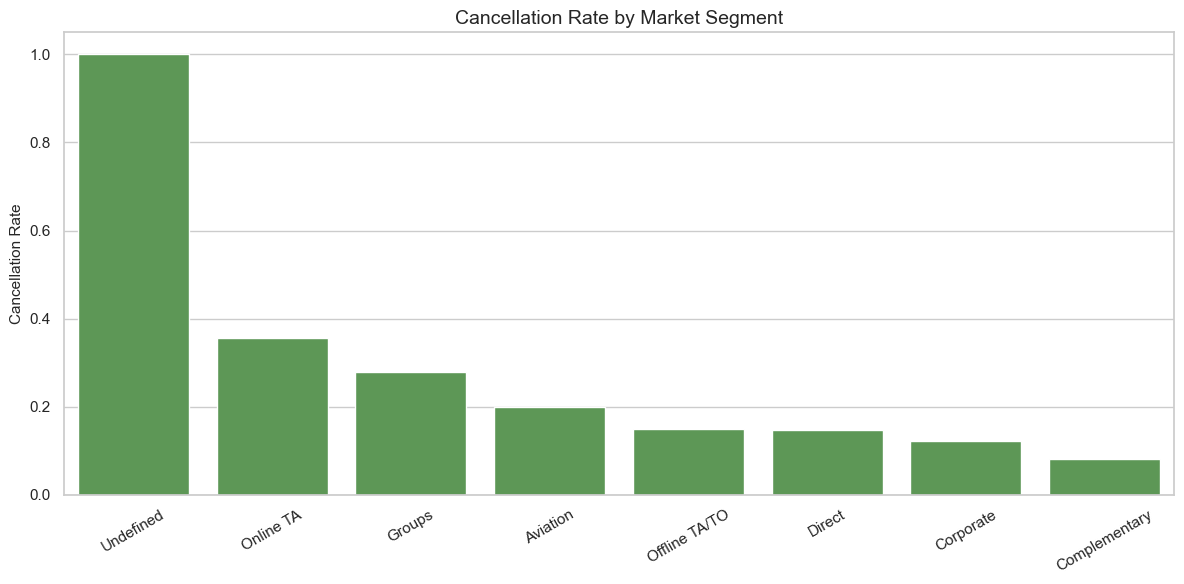

In [ ]:
plt.figure(figsize=(12, 4.8))
sns.barplot(data=market_segment_summary, x="market_segment", y="cancellation_rate", color=OVERALL_COLOR)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



#### 2.4 Distribution Channel


In [ ]:
distribution_summary


,distribution_channel,cancellation_rate,bookings
4,Undefined,0.800000,5
3,TA/TO,0.312522,68280
2,GDS,0.203390,177
1,Direct,0.150000,12220
0,Corporate,0.128059,4904


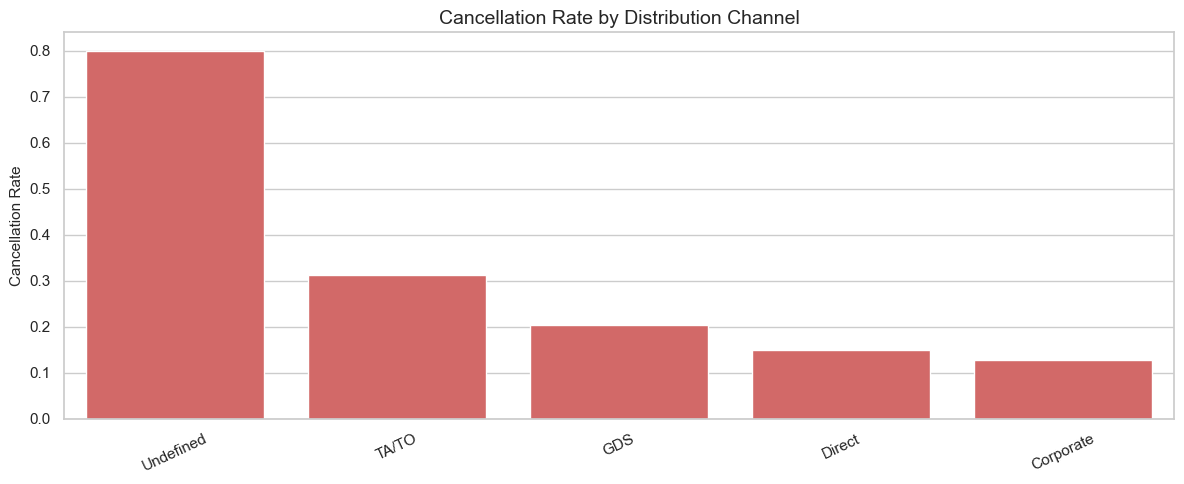

In [ ]:
plt.figure(figsize=(12, 4.8))
sns.barplot(data=distribution_summary, x="distribution_channel", y="cancellation_rate", color=OVERALL_COLOR)
plt.title("Cancellation Rate by Distribution Channel")
plt.xlabel("")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()



#### 2.5 Culture / Origin Market Differences


In [ ]:
country_volume = (
    df_clean.groupby("country")
    .size()
    .reset_index(name="bookings")
)
country_volume["booking_share_pct"] = (
    country_volume["bookings"] / country_volume["bookings"].sum() * 100
).round(2)

top_origin_markets = (
    country_volume[country_volume["booking_share_pct"] > 2]
    .sort_values("bookings", ascending=False)["country"]
    .tolist()
)

country_cancel_summary = (
    df_clean[df_clean["country"].isin(top_origin_markets)]
    .groupby("country")
    .agg(
        bookings=("is_canceled", "size"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean")
    )
    .reset_index()
    .merge(country_volume[["country", "booking_share_pct"]], on="country", how="left")
)

country_cancel_summary = country_cancel_summary.sort_values("bookings", ascending=False)
country_cancel_summary


,country,bookings,cancellation_rate,avg_adr,booking_share_pct
9,PRT,26026,0.369899,101.074071,30.56
5,GBR,10360,0.191409,98.344937,12.17
4,FRA,8785,0.197040,113.187506,10.32
3,ESP,7181,0.259156,123.480231,8.43
2,DEU,5366,0.196236,106.353996,6.30
7,ITA,3049,0.352247,116.711145,3.58
6,IRL,3010,0.221927,100.723518,3.53
0,BEL,2074,0.197203,115.768607,2.44
1,BRA,1981,0.366482,113.474427,2.33
8,NLD,1906,0.183631,109.489061,2.24


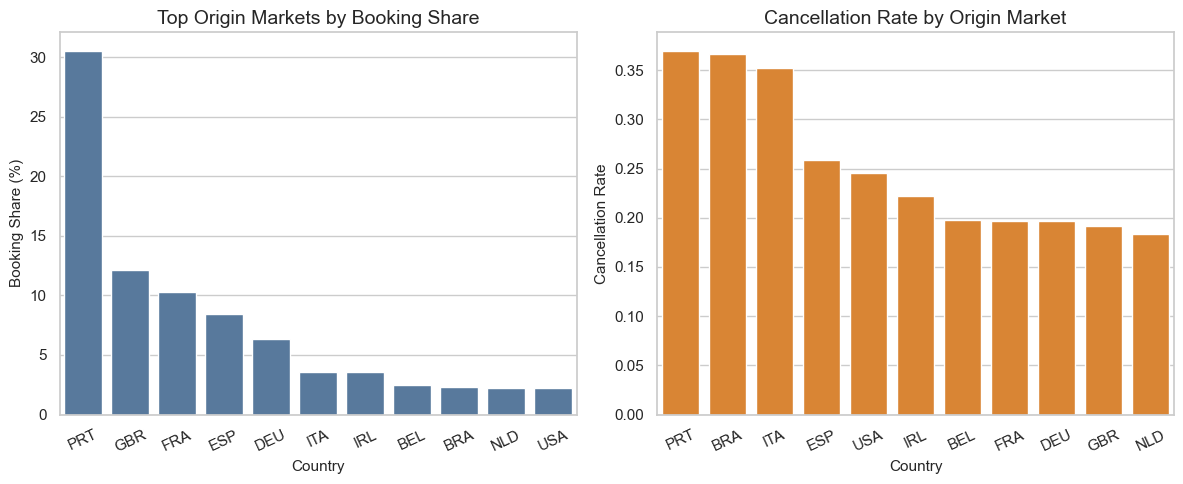

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

sns.barplot(data=country_cancel_summary, x="country", y="booking_share_pct", color=OVERALL_COLOR, ax=axes[0])
axes[0].set_title("Top Origin Markets by Booking Share")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Booking Share (%)")
axes[0].tick_params(axis="x", rotation=25)

country_cancel_plot = country_cancel_summary.sort_values("cancellation_rate", ascending=False)
sns.barplot(data=country_cancel_plot, x="country", y="cancellation_rate", color=OVERALL_COLOR, ax=axes[1])
axes[1].set_title("Cancellation Rate by Origin Market")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Cancellation Rate")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()



#### 2.6 Loyalty


In [ ]:
display(repeat_guest_summary)
display(previous_cancel_summary.head(10))


,is_repeated_guest,cancellation_rate,bookings
0,0,0.285478,82665
1,1,0.082506,2921


,previous_cancellations,cancellation_rate,bookings
9,14,1.000000,1
10,19,1.000000,1
11,21,1.000000,1
12,24,1.000000,2
13,25,1.000000,2
14,26,1.000000,1
1,1,0.767544,1368
8,13,0.750000,4
2,2,0.344086,93
3,3,0.277778,54


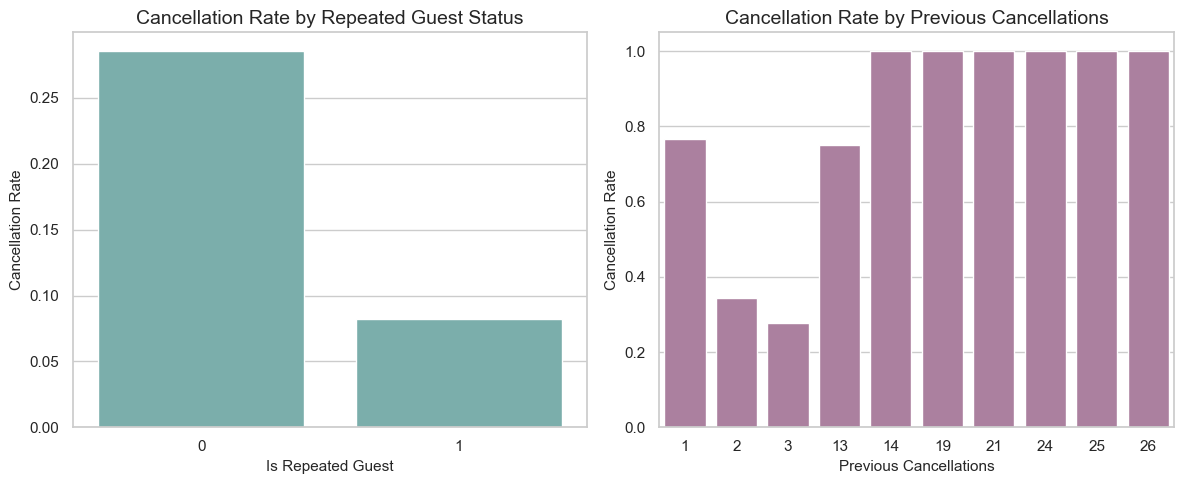

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

sns.barplot(data=repeat_guest_summary, x="is_repeated_guest", y="cancellation_rate", color=OVERALL_COLOR, ax=axes[0])
axes[0].set_title("Cancellation Rate by Repeated Guest Status")
axes[0].set_xlabel("Is Repeated Guest")
axes[0].set_ylabel("Cancellation Rate")

sns.barplot(data=previous_cancel_summary.head(10), x="previous_cancellations", y="cancellation_rate", color=OVERALL_COLOR, ax=axes[1])
axes[1].set_title("Cancellation Rate by Previous Cancellations")
axes[1].set_xlabel("Previous Cancellations")
axes[1].set_ylabel("Cancellation Rate")

plt.tight_layout()
plt.show()



### Question 3. What Factors Most Strongly Predict Cancellations?

As a simple EDA-based comparison, we rank driver strength by the spread between the highest and lowest cancellation rates within each factor.


In [ ]:
driver_strength = pd.DataFrame([
    ["lead_time_group", lead_time_summary["cancellation_rate"].max() - lead_time_summary["cancellation_rate"].min()],
    ["deposit_type", deposit_driver_summary["cancellation_rate"].max() - deposit_driver_summary["cancellation_rate"].min()],
    ["market_segment", market_segment_summary["cancellation_rate"].max() - market_segment_summary["cancellation_rate"].min()],
    ["distribution_channel", distribution_summary["cancellation_rate"].max() - distribution_summary["cancellation_rate"].min()],
    ["origin_market_country", country_cancel_summary["cancellation_rate"].max() - country_cancel_summary["cancellation_rate"].min()],
    ["is_repeated_guest", repeat_guest_summary["cancellation_rate"].max() - repeat_guest_summary["cancellation_rate"].min()],
    ["previous_cancellations", previous_cancel_summary["cancellation_rate"].max() - previous_cancel_summary["cancellation_rate"].min()]
], columns=["driver", "rate_difference"])

driver_strength = driver_strength.sort_values("rate_difference", ascending=False).reset_index(drop=True)
driver_strength


,driver,rate_difference
0,previous_cancellations,0.925926
1,market_segment,0.919355
2,deposit_type,0.704023
3,distribution_channel,0.671941
4,lead_time_group,0.392170
5,is_repeated_guest,0.202972
6,origin_market_country,0.186269


## Key Insights

Use this section to summarize the strongest findings in short business language.

- Which hotel type faces the more severe cancellation problem?
- Which factors show the largest differences in cancellation rate?
- Which driver appears most actionable from an operations or policy perspective?


## Validation

At this stage, the analysis is descriptive. The next validation step is to check whether the strongest EDA findings remain important in a simple predictive model.


## Conclusion

This notebook is designed as the focused EDA foundation for a later ML comparison. The immediate goal is not to model everything at once, but to build a clear, defensible story about cancellation severity, its revenue implications, and the most important candidate drivers.
